# Konkan Canara - Elastic Net + U-Net Hybrid Model for Relative Humidity Prediction (4-Step Input Sequence)

In [1]:
# Importing the required libraries
import numpy as np
import joblib
import importlib
    
import random
import gc

import torch
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

import KC_Data_Preprocessing as KCD
import Baseline_Model_Definitions as BMD
import UNet_Model_Definitions as UMD
import UNet_Model_Utils as UMU

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
torch.cuda.get_device_properties()

_CudaDeviceProperties(name='NVIDIA GeForce RTX 4060 Laptop GPU', major=8, minor=9, total_memory=8187MB, multi_processor_count=24, uuid=a73fa0eb-512f-ffe4-cf94-f2e7b26c980c, pci_bus_id=1, pci_device_id=0, pci_domain_id=0, L2_cache_size=32MB)

In [5]:
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

In [6]:
torch.cuda.init()

In [7]:
gc.collect()
torch.cuda.empty_cache()

## Data Loading and Preprocessing

In [8]:
importlib.reload(KCD);

In [9]:
feature_scaler = joblib.load('feature_scaler_rh.pkl')
target_scaler = joblib.load('target_scaler_rh.pkl')

SEQ_LEN = 4

data = KCD.prepare_konkan_data(
    file_path='KC_6H_2001-2025_Final.csv', 
    feature_scaler=feature_scaler, 
    target_scaler=target_scaler, 
    seq_len=SEQ_LEN, 
    target_variable='rh'
)

X_train, y_train = data['train']
X_val, y_val = data['val']

height = data['meta']['height']
width = data['meta']['width']
num_channels = data['meta']['channels'] 
feature_names = data['meta']['feature_names']

print(f'X_train shape: {X_train.shape} (2001-2018)')
print(f'X_val shape: {X_val.shape} (2019-2020)')

X_train shape: (26292, 4, 32, 12, 8) (2001-2018)
X_val shape: (2924, 4, 32, 12, 8) (2019-2020)


In [10]:
feature_names

['msl', 'sst', 'u10', 'v10', 'ws', 't2m', 'rh', 'tp']

In [11]:
height, width, num_channels

(32, 12, 8)

### Reshaping the data for Elastic Net

In [12]:
# Reshape X_train from (26292, SEQ_LEN, 32, 12, 8) to (26292, SEQ_LEN * 32 * 12 * 8)
X_train_flat = X_train.reshape(X_train.shape[0], -1) 

# Reshape y_train from (26292, 32, 12, 1) to (26292, 32 * 12 * 1)
y_train_flat = y_train.reshape(y_train.shape[0], -1)

X_val_flat = X_val.reshape(X_val.shape[0], -1)
y_val_flat = y_val.reshape(y_val.shape[0], -1)

print(f'--- Flattened Shapes for Elastic Net ---')
print(f'Train: X={X_train_flat.shape}, y={y_train_flat.shape}')
print(f'Val: X={X_val_flat.shape}, y={y_val_flat.shape}')

X_train_flat_tensor = torch.as_tensor(X_train_flat, dtype=torch.float32).to(device)
y_train_flat_tensor = torch.as_tensor(y_train_flat, dtype=torch.float32).to(device)

X_val_flat_tensor = torch.as_tensor(X_val_flat, dtype=torch.float32).to(device)
y_val_flat_tensor = torch.as_tensor(y_val_flat, dtype=torch.float32).to(device)

--- Flattened Shapes for Elastic Net ---
Train: X=(26292, 12288), y=(26292, 384)
Val: X=(2924, 12288), y=(2924, 384)


## PyTorch Elastic Net Baseline

In [13]:
importlib.reload(BMD);

In [14]:
input_dim = X_train_flat.shape[1] # 12288
output_dim = y_train_flat.shape[1] # 384

el_model = BMD.PyTorchElasticNet(input_dim=input_dim, output_dim=output_dim, 
                                   alpha=0.01, l1_ratio=0.5).to(device)

In [15]:
summary(el_model, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
PyTorchElasticNet                        [1, 384]                  --
├─Linear: 1-1                            [1, 384]                  4,718,976
Total params: 4,718,976
Trainable params: 4,718,976
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.72
Input size (MB): 0.05
Forward/backward pass size (MB): 0.00
Params size (MB): 18.88
Estimated Total Size (MB): 18.93

In [16]:
LR = 0.001
EP = 50
BATCH_SIZE_EL = 128

In [17]:
torch.cuda.synchronize()
start_event.record()

history = el_model.fit(
    X_train_flat_tensor, y_train_flat_tensor, 
    X_val_flat_tensor, y_val_flat_tensor, 
    lr=LR, 
    epochs=EP, 
    batch_size=BATCH_SIZE_EL
)

end_event.record()
torch.cuda.synchronize()

In [18]:
elapsed_time_elnet = start_event.elapsed_time(end_event)
elnet_duration = elapsed_time_elnet / 1000

minutes, seconds = divmod(elnet_duration, 60)

if minutes > 0:
    print(f'ElasticNet Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'ElasticNet Training Time: {seconds:.2f} seconds')

ElasticNet Training Time: 31.00 seconds


In [19]:
torch.save(el_model.state_dict(), 'ElasticNet_4S_RH.pth');

In [20]:
gc.collect()
torch.cuda.empty_cache()

### Generating hints and data loaders for the U-Net models

In [21]:
el_model.eval()

with torch.inference_mode():
    # Generating hints -> shape of the hints is (N, 384)
    el_hint_train_flat = el_model(X_train_flat_tensor)
    el_hint_val_flat = el_model(X_val_flat_tensor)

# Reshape hints back to spatial grid (N, 1, H, W) directly on GPU -> 384 becomes (1, 32, 12)
el_hint_train_tensor = el_hint_train_flat.view(-1, 1, height, width)
el_hint_val_tensor = el_hint_val_flat.view(-1, 1, height, width)

# Preparing Last-Step Features
X_train_last = torch.from_numpy(X_train[:, -1, :, :, :]).float().to(device).permute(0, 3, 1, 2)
X_val_last = torch.from_numpy(X_val[:, -1, :, :, :]).float().to(device).permute(0, 3, 1, 2)

# Concatenating Features + Hint Channel (N, 8+1, 32, 12)
hybrid_X_train_tensor = torch.cat([X_train_last, el_hint_train_tensor], dim=1)
hybrid_X_val_tensor = torch.cat([X_val_last, el_hint_val_tensor], dim=1)

# Targets
y_train_tensor = torch.from_numpy(y_train).float().to(device).permute(0, 3, 1, 2)
y_val_tensor = torch.from_numpy(y_val).float().to(device).permute(0, 3, 1, 2)

print(f'Hybrid Input Shapes: Train={hybrid_X_train_tensor.shape}, Val={hybrid_X_val_tensor.shape}')

Hybrid Input Shapes: Train=torch.Size([26292, 9, 32, 12]), Val=torch.Size([2924, 9, 32, 12])


In [22]:
BATCH_SIZE_UNET = 128

unet_train_loader = DataLoader(
    TensorDataset(hybrid_X_train_tensor, y_train_tensor), 
    batch_size=BATCH_SIZE_UNET, 
    shuffle=True,     
    pin_memory=False
)

unet_val_loader = DataLoader(
    TensorDataset(hybrid_X_val_tensor, y_val_tensor), 
    batch_size=BATCH_SIZE_UNET, 
    shuffle=False, 
    pin_memory=False
)

## U-Net Models

In [24]:
importlib.reload(UMU);
importlib.reload(UMD);

In [25]:
unet_loss_fn = torch.nn.GaussianNLLLoss(eps=1e-6, full=True, reduction='none')

In [26]:
INPUT_CHANNELS_UNET = num_channels + 1
OUTPUT_CHANNELS_UNET = 2
UNET_EPOCHS  = 50

### Standard U-Net

In [27]:
hybrid_model1 = UMD.Standard_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model1)

In [28]:
summary(hybrid_model1, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width)) 

Layer (type:depth-idx)                        Output Shape              Param #
Standard_UNet                                 [128, 2, 32, 12]          --
├─BaseDoubleConv: 1-1                         [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                         [128, 64, 32, 12]         --
├─BaseDown: 1-2                               [128, 128, 16, 6]         --
│    └─Sequential: 2-2                        [128, 128, 16, 6]         --
│    │    └─LPPool2d: 3-7                     [128, 64, 16, 6]          --
│    │    └

In [29]:
gc.collect()
torch.cuda.empty_cache()

In [30]:
torch.cuda.synchronize()
start_event.record()

train_losses1, val_losses1, lr_history1 = UMU.train_model(
    hybrid_model1, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: 0.120211 | Val Loss: -0.187245 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.410599 | Val Loss: -0.633756 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.838533 | Val Loss: -1.049669 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.239726 | Val Loss: -1.372889 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.576888 | Val Loss: -1.596037 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -2.358088 | Val Loss: -2.092061 | LR: 1.00e-08


Epoch 47 | Train Loss: -2.358193 | Val Loss: -2.091979 | LR: 1.00e-08


Epoch 48 | Train Loss: -2.358111 | Val Loss: -2.092021 | LR: 1.00e-08


Epoch 49 | Train Loss: -2.358120 | Val Loss: -2.091737 | LR: 1.00e-08


Epoch 50 | Train Loss: -2.358084 | Val Loss: -2.091791 | LR: 1.00e-08


In [31]:
elapsed_time_unet1 = start_event.elapsed_time(end_event)
unet_duration1 = elapsed_time_unet1 / 1000

minutes, seconds = divmod(unet_duration1, 60)

if minutes > 0:
    print(f'Standard U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Standard U-Net Training Time: {seconds:.2f} seconds')

Standard U-Net Training Time: 6 minutes and 4.78 seconds


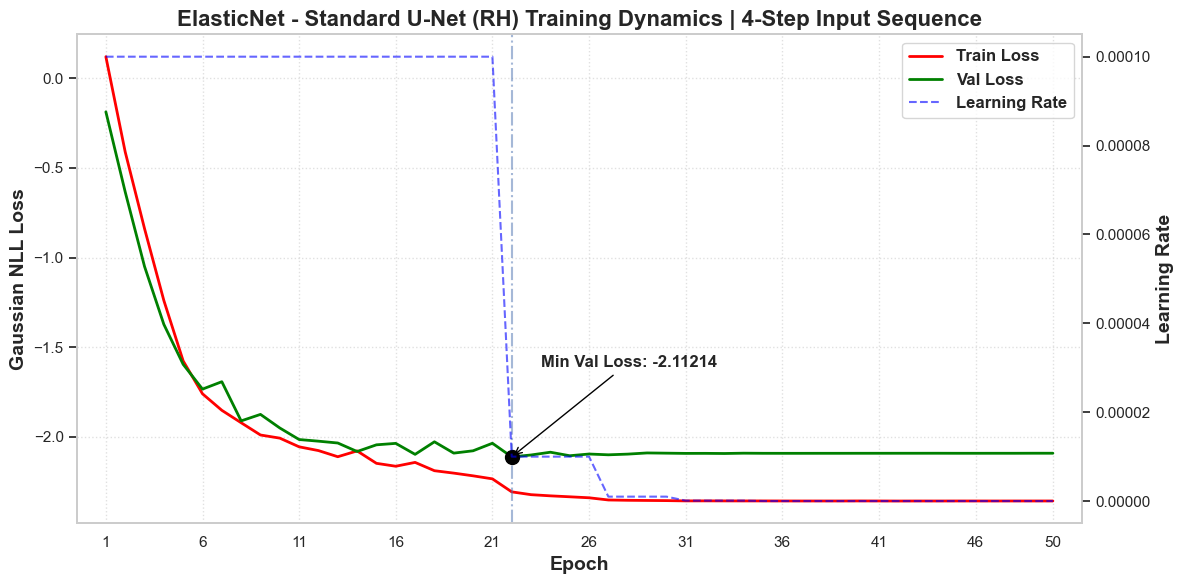

In [32]:
UMU.plot_training_dynamics(train_losses1, val_losses1, lr_history1, 
                       'ElasticNet - Standard U-Net (RH)', SEQ_LEN)

In [33]:
torch.save(hybrid_model1.state_dict(), 'ElasticNet_Standard_U-Net_Hybrid_RH_4S.pth')

In [34]:
del hybrid_model1, 
del optimizer
del scheduler

In [35]:
gc.collect()
torch.cuda.empty_cache()

### Residual U-Net

In [36]:
hybrid_model2 = UMD.Residual_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model2)

In [37]:
summary(hybrid_model2, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                        Output Shape              Param #
Residual_UNet                                 [128, 2, 32, 12]          --
├─ResidualDoubleConv: 1-1                     [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    └─Sequential: 2-2                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-6                       [128, 64, 32, 12]         576
│    │    └─GroupNorm: 3-7                    [128, 64, 32, 12]         128
│    └─ReLU: 2-3                              [128, 64, 32, 12]         --
├─BaseDow

In [38]:
gc.collect()
torch.cuda.empty_cache()

In [39]:
torch.cuda.synchronize()
start_event.record()

train_losses2, val_losses2, lr_history2 = UMU.train_model(
    hybrid_model2, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: -0.252848 | Val Loss: -0.701494 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.986759 | Val Loss: -1.149926 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -1.445419 | Val Loss: -1.619708 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.739543 | Val Loss: -1.818096 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.866951 | Val Loss: -1.889631 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -2.448151 | Val Loss: -1.983936 | LR: 1.00e-08


Epoch 47 | Train Loss: -2.448025 | Val Loss: -1.983938 | LR: 1.00e-08


Epoch 48 | Train Loss: -2.448067 | Val Loss: -1.983940 | LR: 1.00e-08


Epoch 49 | Train Loss: -2.448149 | Val Loss: -1.983796 | LR: 1.00e-08


Epoch 50 | Train Loss: -2.448173 | Val Loss: -1.983629 | LR: 1.00e-08


In [40]:
elapsed_time_unet2 = start_event.elapsed_time(end_event)
unet_duration2 = elapsed_time_unet2 / 1000

minutes, seconds = divmod(unet_duration2, 60)

if minutes > 0:
    print(f'Residual U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Residual U-Net Training Time: {seconds:.2f} seconds')

Residual U-Net Training Time: 7 minutes and 33.04 seconds


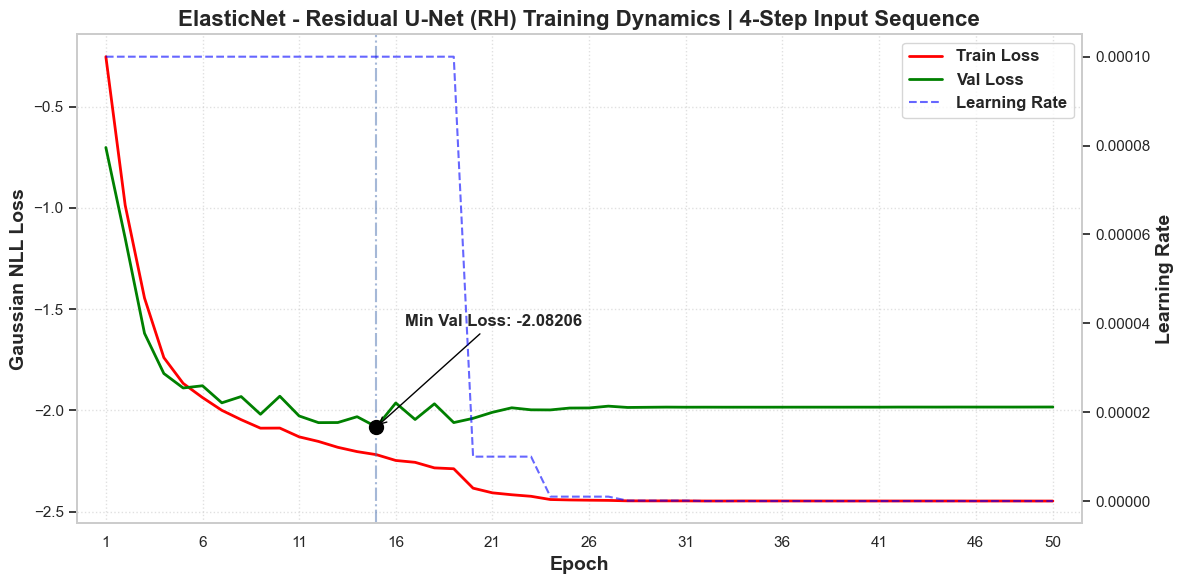

In [41]:
UMU.plot_training_dynamics(train_losses2, val_losses2, lr_history2, 
                       'ElasticNet - Residual U-Net (RH)', SEQ_LEN)

In [42]:
torch.save(hybrid_model2.state_dict(), 'ElasticNet_Residual_U-Net_Hybrid_RH_4S.pth')

In [43]:
del hybrid_model2, 
del optimizer
del scheduler

In [44]:
gc.collect()
torch.cuda.empty_cache()

### Attention U-Net

In [45]:
hybrid_model3 = UMD.Attention_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model3)

In [46]:
summary(hybrid_model3, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                        Output Shape              Param #
Attention_UNet                                [128, 2, 32, 12]          --
├─BaseDoubleConv: 1-1                         [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                         [128, 64, 32, 12]         --
├─BaseDown: 1-2                               [128, 128, 16, 6]         --
│    └─Sequential: 2-2                        [128, 128, 16, 6]         --
│    │    └─LPPool2d: 3-7                     [128, 64, 16, 6]          --
│    │    └

In [47]:
gc.collect()
torch.cuda.empty_cache()

In [48]:
torch.cuda.synchronize()
start_event.record()

train_losses3, val_losses3, lr_history3 = UMU.train_model(
    hybrid_model3, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: 0.314813 | Val Loss: -0.032407 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.294839 | Val Loss: -0.547765 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.771658 | Val Loss: -0.987212 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.190278 | Val Loss: -1.379299 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.515076 | Val Loss: -1.648967 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -2.318630 | Val Loss: -2.079714 | LR: 1.00e-08


Epoch 47 | Train Loss: -2.318537 | Val Loss: -2.079602 | LR: 1.00e-08


Epoch 48 | Train Loss: -2.318201 | Val Loss: -2.079527 | LR: 1.00e-08


Epoch 49 | Train Loss: -2.318432 | Val Loss: -2.079580 | LR: 1.00e-08


Epoch 50 | Train Loss: -2.318508 | Val Loss: -2.079662 | LR: 1.00e-08


In [49]:
elapsed_time_unet3 = start_event.elapsed_time(end_event)
unet_duration3 = elapsed_time_unet3 / 1000

minutes, seconds = divmod(unet_duration3, 60)

if minutes > 0:
    print(f'Attention U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Attention U-Net Training Time: {seconds:.2f} seconds')

Attention U-Net Training Time: 7 minutes and 28.03 seconds


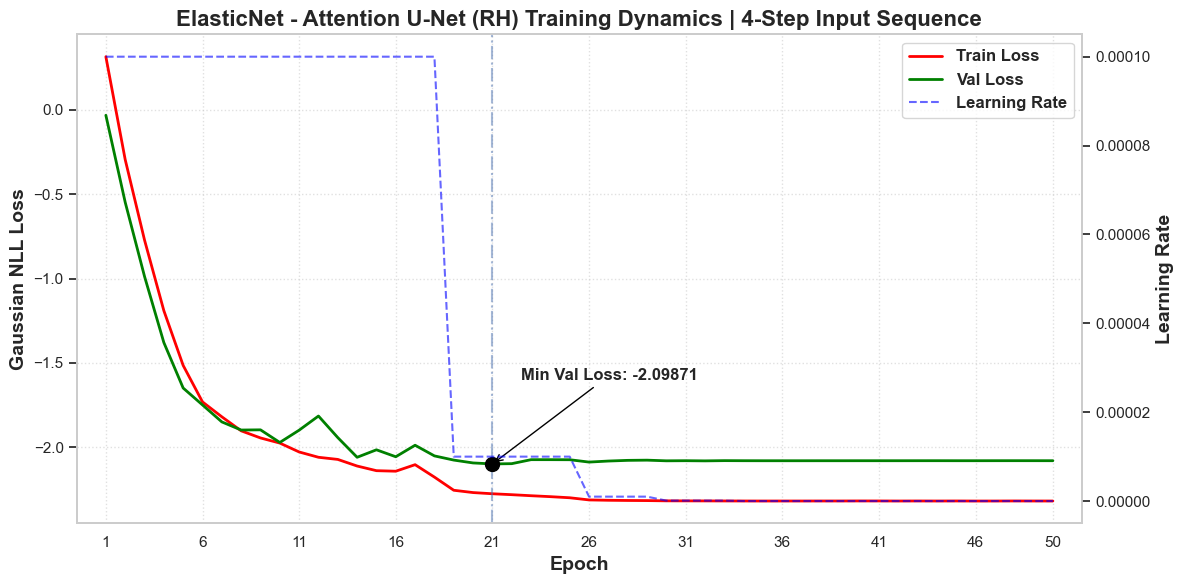

In [50]:
UMU.plot_training_dynamics(train_losses3, val_losses3, lr_history3, 
                       'ElasticNet - Attention U-Net (RH)', SEQ_LEN)

In [51]:
torch.save(hybrid_model3.state_dict(), 'ElasticNet_Attention_U-Net_Hybrid_RH_4S.pth')

In [52]:
del hybrid_model3
del optimizer
del scheduler

In [53]:
gc.collect()
torch.cuda.empty_cache()

### CBAM (Convolution Block Attention Module) U-Net

In [54]:
hybrid_model4 = UMD.CBAM_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model4)

In [55]:
summary(hybrid_model4, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                             Output Shape              Param #
CBAM_UNet                                          [128, 2, 32, 12]          --
├─CBAMDoubleConv: 1-1                              [128, 64, 32, 12]         --
│    └─Sequential: 2-1                             [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                            [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                         [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                              [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                            [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                         [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                              [128, 64, 32, 12]         --
│    └─ChannelAttention: 2-2                       [128, 64, 1, 1]           --
│    │    └─AdaptiveAvgPool2d: 3-7                 [128, 64, 1, 1]           --
│    │    └─Sequential: 3-

In [56]:
gc.collect()
torch.cuda.empty_cache()

In [57]:
torch.cuda.synchronize()
start_event.record()

train_losses4, val_losses4, lr_history4 = UMU.train_model(
    hybrid_model4, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: 0.099044 | Val Loss: -0.181372 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.392360 | Val Loss: -0.603984 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.823332 | Val Loss: -0.984319 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.221105 | Val Loss: -1.377542 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.550908 | Val Loss: -1.635439 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -2.413662 | Val Loss: -2.004279 | LR: 1.00e-08


Epoch 47 | Train Loss: -2.413572 | Val Loss: -2.004116 | LR: 1.00e-08


Epoch 48 | Train Loss: -2.413807 | Val Loss: -2.004342 | LR: 1.00e-08


Epoch 49 | Train Loss: -2.413757 | Val Loss: -2.004187 | LR: 1.00e-08


Epoch 50 | Train Loss: -2.413773 | Val Loss: -2.004154 | LR: 1.00e-08


In [58]:
elapsed_time_unet4 = start_event.elapsed_time(end_event)
unet_duration4 = elapsed_time_unet4 / 1000

minutes, seconds = divmod(unet_duration4, 60)

if minutes > 0:
    print(f'CBAM U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'CBAM U-Net Training Time: {seconds:.2f} seconds')

CBAM U-Net Training Time: 7 minutes and 30.40 seconds


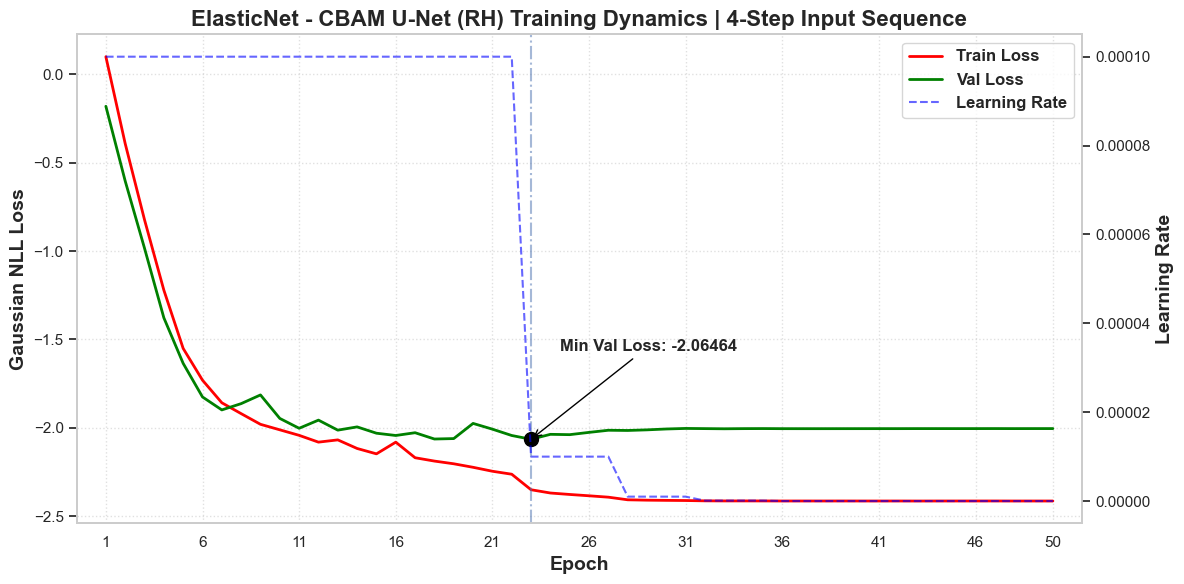

In [59]:
UMU.plot_training_dynamics(train_losses4, val_losses4, lr_history4, 
                       'ElasticNet - CBAM U-Net (RH)', SEQ_LEN)

In [60]:
torch.save(hybrid_model4.state_dict(), 'ElasticNet_CBAM_U-Net_Hybrid_RH_4S.pth')

In [61]:
del hybrid_model4 
del optimizer
del scheduler

In [62]:
gc.collect()
torch.cuda.empty_cache()

## Total Training Time for Each Hybrid Model

In [63]:
total_duration1 = elnet_duration + unet_duration1
minutes, seconds = divmod(total_duration1, 60)

if minutes > 0:
    print(f'Total Training Time for ElasticNet - Standard U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for ElasticNet - Standard U-Net: {seconds:.2f} seconds')

Total Training Time for ElasticNet - Standard U-Net: 6 minutes and 35.79 seconds


In [64]:
total_duration2 = elnet_duration + unet_duration2
minutes, seconds = divmod(total_duration2, 60)

if minutes > 0:
    print(f'Total Training Time for ElasticNet - Residual U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for ElasticNet - Residual U-Net: {seconds:.2f} seconds')

Total Training Time for ElasticNet - Residual U-Net: 8 minutes and 4.05 seconds


In [65]:
total_duration3 = elnet_duration + unet_duration3
minutes, seconds = divmod(total_duration3, 60)

if minutes > 0:
    print(f'Total Training Time for ElasticNet - Attention U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for ElasticNet - Attention U-Net: {seconds:.2f} seconds')

Total Training Time for ElasticNet - Attention U-Net: 7 minutes and 59.04 seconds


In [66]:
total_duration4 = elnet_duration + unet_duration4
minutes, seconds = divmod(total_duration4, 60)

if minutes > 0:
    print(f'Total Training Time for ElasticNet - CBAM U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for ElasticNet - CBAM U-Net: {seconds:.2f} seconds')

Total Training Time for ElasticNet - CBAM U-Net: 8 minutes and 1.40 seconds


***